<a href="https://colab.research.google.com/github/gautamkushwaha/50-days-of-coding/blob/main/Deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/10 | Train Loss: 0.2393 | Val Loss: 0.1559
Epoch 2/10 | Train Loss: 0.0936 | Val Loss: 0.1053
Epoch 3/10 | Train Loss: 0.0649 | Val Loss: 0.1051
Epoch 4/10 | Train Loss: 0.0454 | Val Loss: 0.0956
Epoch 5/10 | Train Loss: 0.0369 | Val Loss: 0.1014
Epoch 6/10 | Train Loss: 0.0329 | Val Loss: 0.0823
Epoch 7/10 | Train Loss: 0.0248 | Val Loss: 0.0905
Epoch 8/10 | Train Loss: 0.0238 | Val Loss: 0.1018
Epoch 9/10 | Train Loss: 0.0215 | Val Loss: 0.1058
Epoch 10/10 | Train Loss: 0.0180 | Val Loss: 0.1221

--- Final Performance Report ---
              precision    recall  f1-score   support

           0     0.9868    0.9949    0.9909       980
           1     0.9938    0.9859    0.9898      1135
           2     0.9640    0.9874    0.9756      1032
           3     0.9918    0.9525    0.9717      1010
           4     0.9886    0.9715    0.9800       982
           5     0.9852    0.9709    0.9780       892
           6     0.9885    0.9854    0.9869       958
           7     0.980

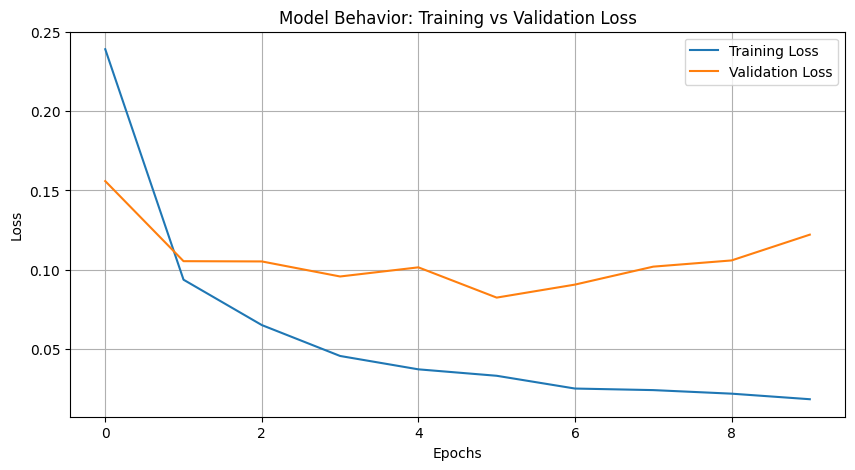

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report

# 1. SETUP & DATA PREPARATION
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load and split: 80% Train, 20% Validation
full_train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_data, val_data = random_split(full_train_dataset, [train_size, val_size])
test_data = datasets.MNIST(root='./data', train=False, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# 2. DEFINE THE BEST PERFORMING MODEL [1024, 512, 256]
class BestMLP(nn.Module):
    def __init__(self):
        super(BestMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(784, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = x.view(-1, 784)
        return self.network(x)

model = BestMLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

# 3. TRAINING LOOP WITH VALIDATION TRACKING
epochs = 10
history = {'train_loss': [], 'val_loss': []}

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    valid_loss = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            valid_loss += loss.item()

    history['train_loss'].append(train_loss/len(train_loader))
    history['val_loss'].append(valid_loss/len(val_loader))
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {history['train_loss'][-1]:.4f} | Val Loss: {history['val_loss'][-1]:.4f}")

# 4. FINAL EVALUATION (Test Set)
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().tolist())
        y_pred.extend(predicted.cpu().tolist())

# OUTPUT RESULTS
print("\n--- Final Performance Report ---")
print(classification_report(y_true, y_pred, digits=4))

# PLOT LOSS CURVES
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Model Behavior: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()